In [ ]:
import zipfile
zip_ref=zipfile.ZipFile("/content/archive (1).zip")
zip_ref.extractall("/content")
zip_ref.close()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/UpdatedResumeDataSet.csv")

In [4]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
df.shape

(962, 2)

In [6]:
df['Category'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Blockchain,40
ETL Developer,40


<Axes: xlabel='count', ylabel='Category'>

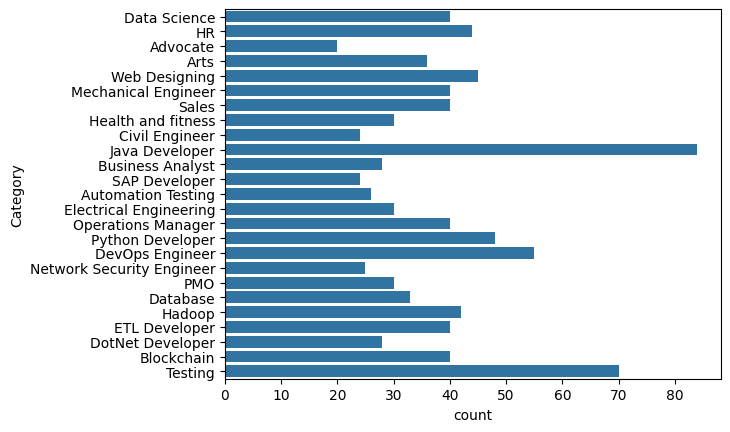

In [7]:
sns.countplot(df['Category'])

In [8]:
df['Category'][0]

'Data Science'

In [9]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

In [10]:
import re
def clean(txt):
  cleanedText=re.sub('https\S+',' ',txt)
  cleanedText=re.sub('@\S+',' ',cleanedText)
  cleanedText=re.sub('#\S+',' ',cleanedText)
  cleanedText=re.sub('[%s]' % re.escape("""!@#$%^&*()_+-=[]{}|;:'\",.<>/?"""),' ',cleanedText)
  cleanedText=re.sub('\s+',' ',cleanedText)
  cleanedText = re.sub(r'[^\x00-\x7f]', ' ', cleanedText)
  return cleanedText

In [11]:
df['Resume']=df['Resume'].apply(lambda x:clean(x))

In [12]:
df['Resume'][0]

'Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na  ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in accelerating th

In [13]:
df.Category.unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Category']=le.fit_transform(df['Category'])

In [15]:
df.Category.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [16]:
from sklearn.feature_extraction.text import  TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')
tfidf.fit(df.Resume)
input=tfidf.transform(df['Resume'])

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(input,df['Category'],test_size=0.2,random_state=42)

In [18]:
x_train.shape

(769, 7350)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
clf=OneVsRestClassifier(KNeighborsClassifier())
clf.fit(x_train,y_train)
ypred=clf.predict(x_test)
print(ypred)

[15 15 15 13 14 17 16  2  0 14 13 12 16 23 20  5  6  4 10  9 19  1 10 23
 23 21 22 22  2 12 18  1  8 24 11 23  7 12 24  8 18  6  8 19 24 23 21  1
 15  4 15 22 11  5 15 13  1 19  5 12 22 22 20 24 21 18 12 10 10 20 10  8
  9 21 17 21  0 17 16 14 15 11 11  8 20  3 19  8  0  2  9 10  2 23 20 20
 23 12 18 12  7 16  8 14 18  3 14 19 14 14 15 18  8  2 21 18 23 10 23  5
 11 15 12  3  5  3  7 12 19  8 20 19  3 15  9 19  1 23 21  5 20 15 16  7
  7  8 15 18  1 15 13 20  7  4 18 11  5 15  5 12  9 22 18 21  8 23  4 12
 24 16 15 22  8 22  3 16 23 23 12  7 16 18  5  3 18  8 23 23 20 21  6  7
 23]


In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,ypred)

0.9844559585492227

<Axes: >

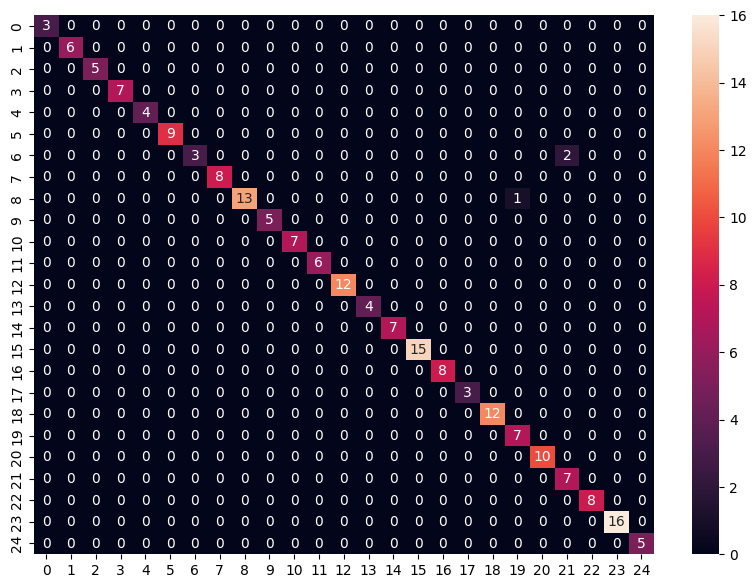

In [21]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,ypred)
plt.figure(figsize = (10, 7))
sns.heatmap(cm, annot = True, fmt = 'd')

In [22]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(clf, open('clf.pkl', 'wb'))

In [23]:
myresume="""Skills Programming Languages: Python (pandas, numpy, scipy, scikit-learn, tensorflow, keras), SQL, Java, JavaScript/React, HTML/CSS.
Machine Learning: Classification (Logistic Regression, Naïve Bayes, Decision Trees), Clustering (K-Means, Hierarchical Clustering), Neural Networks (CNN, RNN, LSTM), NLP (Sentiment Analysis, Named Entity Recognition, Topic Modeling), Dimensionality Reduction (PCA, t-SNE).
Database & Visualizations: MySQL, PostgreSQL, MongoDB, ElasticSearch, Kibana, Tableau, Power BI, matplotlib, Plotly, D3.js.
Others: Docker, Flask, Git, CI/CD, AWS (EC2, S3, RDS), REST APIs, Agile methodologies.
Education Details

Master’s in Computer Science
Role: Data Engineer
Data Engineer - XYZ Analytics

Company: XYZ Analytics
Description: Provided data engineering solutions for enhancing data pipelines, real-time processing, and ETL workflows in the retail sector.
Project Details
CUSTOMER SEGMENTATION FOR TARGETED MARKETING
Objective: Developed a customer segmentation model to enable targeted marketing strategies.
Responsibilities:
Preprocessed customer transaction data, exploring demographics, purchase history, and behavior.
Applied K-means clustering to segment customers and identified key groups for personalized campaigns.
Built dashboards for marketing teams to visualize customer segments and engagement metrics.
Tools & Technologies: Python, scikit-learn, SQL, Tableau, Power BI.
REAL-TIME PRODUCT RECOMMENDATION ENGINE
Objective: Built a recommendation system to provide personalized product suggestions in real-time.
Responsibilities:
Collected product interaction data and implemented a collaborative filtering algorithm for recommendations.
Integrated the recommendation engine into the e-commerce platform, improving user experience and increasing sales.
Optimized the recommendation model for scalability and implemented a monitoring system to track performance.
Tools & Technologies: Python, scikit-learn, Flask, SQL, Docker, AWS.
E-COMMERCE SALES FORECASTING
Objective: Developed a time series forecasting model to predict future sales and optimize inventory levels.
Responsibilities:
Analyzed historical sales data and identified seasonal trends and demand fluctuations.
Built and tuned an ARIMA and LSTM model to forecast sales, helping to manage stock more effectively.
Developed dashboards for the supply chain team to monitor forecast accuracy and adjust inventory.
Tools & Technologies: Python, Statsmodels, TensorFlow, SQL, Power BI.
CHATBOT FOR CUSTOMER SERVICE
Objective: Developed a chatbot to handle common customer queries, reducing customer support workload.
Responsibilities:
Designed and implemented a chatbot capable of answering FAQs, providing order updates, and assisting with returns.
Used NLP techniques to understand customer intents and trained the chatbot on typical user interactions.
Integrated the chatbot with backend APIs for real-time responses to customer queries.
Tools & Technologies: Python, NLTK, Rasa, Flask, JavaScript, HTML/CSS.
FRAUD DETECTION SYSTEM FOR ONLINE TRANSACTIONS
Objective: Created a fraud detection system to identify suspicious transactions in real-time.
Responsibilities:
Used historical transaction data to develop anomaly detection models using Isolation Forest and Logistic Regression.
Deployed the model to the production environment, with an alert system to notify analysts of potential fraud cases.
Collaborated with security teams to fine-tune the model based on emerging fraud patterns.
Tools & Technologies: Python, scikit-learn, Flask, PostgreSQL, Kibana, Docker.
SOCIAL MEDIA SENTIMENT ANALYSIS
Objective: Analyzed sentiment from social media posts to help marketing teams understand public perception.
Responsibilities:
Collected data from Twitter and other social media platforms and performed sentiment analysis.
Used NLP methods to classify sentiment (positive, negative, neutral) and tracked brand mentions and trending topics.
Created interactive visualizations to report insights on brand sentiment and customer feedback.
Tools & Technologies: Python, NLTK, Vader, Tableau, Plotly.
Additional Technical Experience
Customer Churn Prediction: Built a model to predict customer churn, identifying high-risk customers and enabling retention strategies.
Data Pipeline Automation: Automated ETL pipelines for data ingestion and processing, ensuring data quality and timeliness.
Log Analysis for Cybersecurity: Developed a log analysis system to detect anomalies and flag potential security threats in real-time."""

In [24]:
resume2="""Skills

Design & Modeling Software: AutoCAD, Revit, Civil 3D, STAAD Pro, SketchUp, Bluebeam
Structural Engineering: Load Calculations, Structural Analysis, Foundation Design, Reinforced Concrete, Steel Structures, Earthquake Resilience
Project Management: Cost Estimation, Resource Planning, Project Scheduling (Microsoft Project, Primavera), Risk Assessment, Field Supervision
Surveying & GIS: Land Surveying, Topographic Mapping, ArcGIS, Drone Survey Analysis
Others: MS Excel (Advanced), Report Writing, Regulatory Compliance, Environmental Impact Analysis
Education Details

Bachelor’s in Civil Engineering
XYZ University, City, State
Role: Civil Engineer
Civil Engineer - XYZ Construction Solutions
City, State
January 2022 – Present

Company: XYZ Construction Solutions
Description: Provides structural and environmental engineering services for large-scale infrastructure projects.
Project Details
BRIDGE CONSTRUCTION PROJECT
Objective: Led the structural analysis and design of a 500-meter suspension bridge, ensuring stability and safety under variable loads.
Responsibilities:
Conducted load calculations and structural analysis to determine materials and reinforcement requirements.
Collaborated with architects, geotechnical engineers, and municipal authorities to align project specifications with regulatory standards.
Supervised on-site construction activities, performing quality control checks on concrete pouring, rebar placement, and formwork.
Tools & Technologies: AutoCAD, STAAD Pro, Civil 3D, Microsoft Project
RESIDENTIAL BUILDING DEVELOPMENT
Objective: Designed and managed the construction of a 30-unit residential complex, focusing on sustainable and earthquake-resistant structures.
Responsibilities:
Created detailed structural drawings and reinforcement plans using AutoCAD and Revit.
Performed seismic analysis to ensure compliance with earthquake resilience codes and standards.
Oversaw field teams for quality assurance and coordinated inspections with local authorities.
Tools & Technologies: Revit, AutoCAD, Civil 3D, MS Excel
ROADWAY IMPROVEMENT AND EXPANSION
Objective: Engineered the expansion of a 10-kilometer highway to reduce congestion and improve traffic flow.
Responsibilities:
Conducted site surveys and collaborated with the surveying team to produce topographic maps and evaluate drainage requirements.
Assisted in designing road layouts, grading plans, and drainage solutions to minimize environmental impact.
Prepared project cost estimates and schedules, coordinating with contractors to ensure adherence to timelines and budget.
Tools & Technologies: Civil 3D, ArcGIS, AutoCAD, Microsoft Project
Additional Technical Experience
Stormwater Management Design: Designed stormwater drainage systems for urban developments, including hydraulic modeling and floodplain analysis.
Environmental Impact Assessments: Assisted in conducting environmental assessments for infrastructure projects, analyzing soil and water samples to meet regulatory compliance.
Project Documentation: Prepared reports, permits, and risk assessments for submission to local and federal authorities.
"""

In [25]:
import pickle
clf = pickle.load(open('clf.pkl', 'rb'))
cleaned_resume = clean(myresume)
input_features = tfidf.transform([cleaned_resume])
prediction_id = clf.predict(input_features)[0]
category_mapping = {
    15: "Java Developer",
    23: "Testing",
    8: "DevOps Engineer",
    20: "Python Developer",
    24: "Web Designing",
    12: "HR",
    13: "Hadoop",
    3: "Blockchain",
    10: "ETL Developer",
    18: "Operations Manager",
    6: "Data Science",
    22: "Sales",
    16: "Mechanical Engineer",
    1: "Arts",
    7: "Database",
    11: "Electrical Engineering",
    14: "Health and fitness",
    19: "PMO",
    4: "Business Analyst",
    9: "DotNet Developer",
    2: "Automation Testing",
    17: "Network Security Engineer",
    21: "SAP Developer",
    5: "Civil Engineer",
    0: "Advocate",
}
cleaned_resume2 = clean(resume2)
input_features2 = tfidf.transform([cleaned_resume2])
prediction_id2 = clf.predict(input_features2)[0]
category_name = category_mapping.get(prediction_id, "Unknown")
print("Predicted Category:", category_name)
category_name2 = category_mapping.get(prediction_id2, "Unknown")
print("Predicted Category:", category_name2)


Predicted Category: Data Science
Predicted Category: Civil Engineer
